# MainCrafts AI & ML Internship – Task 2

## Feature Engineering, Model Optimization & Performance Comparison

### California Housing Price Prediction

**Student:** Ankith M

### Objective

The objective of this project is to improve the California Housing price prediction workflow by applying feature scaling and comparing multiple regression algorithms.

### Models Used

1. Linear Regression
2. Ridge Regression
3. Decision Tree Regressor

### Evaluation Metrics

- RMSE (Root Mean Squared Error)
- R² (R-squared)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
data = fetch_california_housing(as_frame=True)

df = pd.concat(
    [data.data, data.target.rename("HousePrice")],
    axis=1
)

print("Dataset shape:", df.shape)

display(df.head())

Dataset shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
print("Dataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nSummary statistics:")
display(df.describe())

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HousePrice  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

Missing values:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HousePrice    0
dtype: int64

Summary statistics:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [5]:
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (20640, 8)
Target shape: (20640,)


In [6]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature scaling completed.")
print("Scaled data shape:", X_scaled.shape)

Feature scaling completed.
Scaled data shape: (20640, 8)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 16512
Testing samples: 4128


In [8]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=5,
        random_state=42
    )
}

print("Models created successfully!")

for name in models:
    print("-", name)

Models created successfully!
- Linear Regression
- Ridge Regression
- Decision Tree


In [9]:
results = []

for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Predict on test data
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # Store results
    results.append({
        "Model": name,
        "RMSE": rmse,
        "R²": r2
    })

print("All models trained successfully!")

All models trained successfully!


In [10]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

display(results_df)

,Model,RMSE,R²
0,Decision Tree,0.724234,0.599732
1,Ridge Regression,0.745554,0.575819
2,Linear Regression,0.745581,0.575788


In [11]:
print("MODEL PERFORMANCE COMPARISON")
print("=" * 50)

for _, row in results_df.iterrows():
    print(f"\n{row['Model']}")
    print(f"RMSE: {row['RMSE']:.4f}")
    print(f"R²:   {row['R²']:.4f}")

MODEL PERFORMANCE COMPARISON

Decision Tree
RMSE: 0.7242
R²:   0.5997

Ridge Regression
RMSE: 0.7456
R²:   0.5758

Linear Regression
RMSE: 0.7456
R²:   0.5758


## Model Performance Comparison

The three regression models were evaluated using RMSE and R².

- **RMSE:** Lower values indicate smaller prediction errors.
- **R²:** Higher values indicate that the model explains more variation in the target variable.

The results table above allows the performance of Linear Regression, Ridge Regression, and Decision Tree Regressor to be compared using the same test dataset.

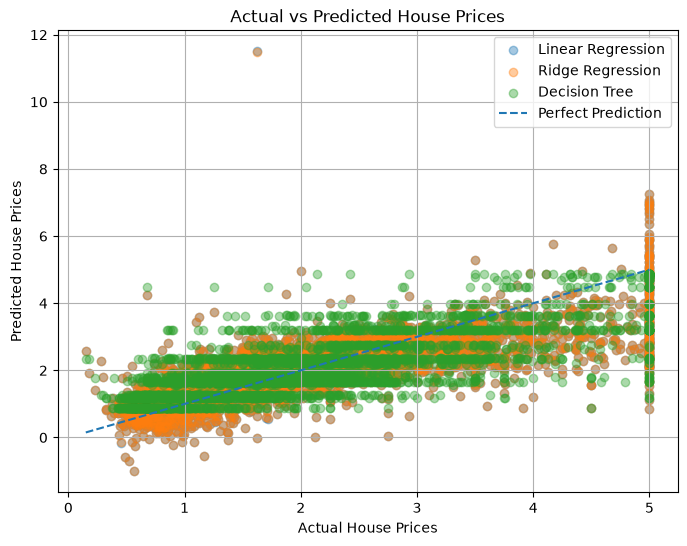

In [12]:
# Actual vs Predicted values for all models

plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_pred = model.predict(X_test)
    plt.scatter(y_test, y_pred, alpha=0.4, label=name)

# Perfect prediction line
min_value = min(y_test.min(), y_test.min())
max_value = max(y_test.max(), y_test.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")
plt.legend()
plt.grid(True)
plt.show()

## Conclusion

Three regression models were implemented and evaluated on the California Housing dataset:

1. Linear Regression
2. Ridge Regression
3. Decision Tree Regressor

The models were compared using RMSE and R² metrics.

The Decision Tree Regressor achieved an RMSE of 0.724234 and an R² score of 0.599732 on the test dataset. Ridge Regression and Linear Regression produced similar results.

Overall, the experiment demonstrates how feature scaling and different regression algorithms can be used to build and compare machine learning models for house price prediction.